# Team fusion model — interactive viewer
Run **Run → Run All Cells**. This loads your frozen two-model fusion and shows plastic-bag predictions beside KITTI ground truth. The image selector and confidence slider let you explore the validation set.

The bundle records **84.5238% organizer 11-point AP@0.5 on 199 validation images**. This is a saved team result, not a newly measured score. This notebook performs inference only.

The original notebooks contain training and submission workflows; those instructions are not needed for this viewer.

In [1]:
from pathlib import Path
import json, sys, torch, ultralytics
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display
import ipywidgets as widgets
# Locate the project from either the repo root or event_materials.
roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((candidate for root in roots
                     for candidate in (root, root / 'uprm-hackathon-2026')
                     if (candidate / 'event_materials' / 'team_fusion.py').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Open this notebook inside the Lockheed-Hackathon repository.')
sys.path.insert(0, str(PROJECT_ROOT / 'event_materials'))
from team_fusion import load_bundle

BUNDLE = PROJECT_ROOT / 'models' / 'team_fusion' / 'v001_84.52_2026-09-27_01h_fusion_bundle.pt'
DATA_ROOT = PROJECT_ROOT / 'data'
DEVICE = '0' if torch.cuda.is_available() else 'cpu'
print('Python:', sys.executable)
print('Ultralytics:', ultralytics.__version__, '| Device:', DEVICE)
assert BUNDLE.is_file(), f'Missing model bundle: {BUNDLE}'
for split in ['training', 'val']:
    images = list((DATA_ROOT / split / 'image').glob('*.jpg'))
    missing = [p.name for p in images if not (DATA_ROOT / split / 'label' / (p.stem + '.txt')).is_file()]
    print(f'{split}: {len(images)} images; {len(missing)} missing labels')
    assert images and not missing, f'Incomplete dataset: {split}'


Python: C:\Users\diego\OneDrive\Documents\GitHub\Lockheed-Hackathon\.venv\Scripts\python.exe
Ultralytics: 8.4.163 | Device: 0
training: 628 images; 0 missing labels
val: 199 images; 0 missing labels


## Load the exact frozen fusion
Both model weights are inside the bundle. Their SHA-256 checksums are checked before loading. The team’s custom weighted-box fusion and test-time augmentation are preserved.

In [2]:
model, config = load_bundle(BUNDLE, PROJECT_ROOT / 'models' / 'team_fusion' / 'extracted', DEVICE)
print('Members:', ', '.join(m['key'] for m in config['members']))
print('Saved organizer AP@0.5:', config['val_map50'])


Members: s90@640+tta, soup_train_m-m768@768+tta
Saved organizer AP@0.5: 0.8452377969568426


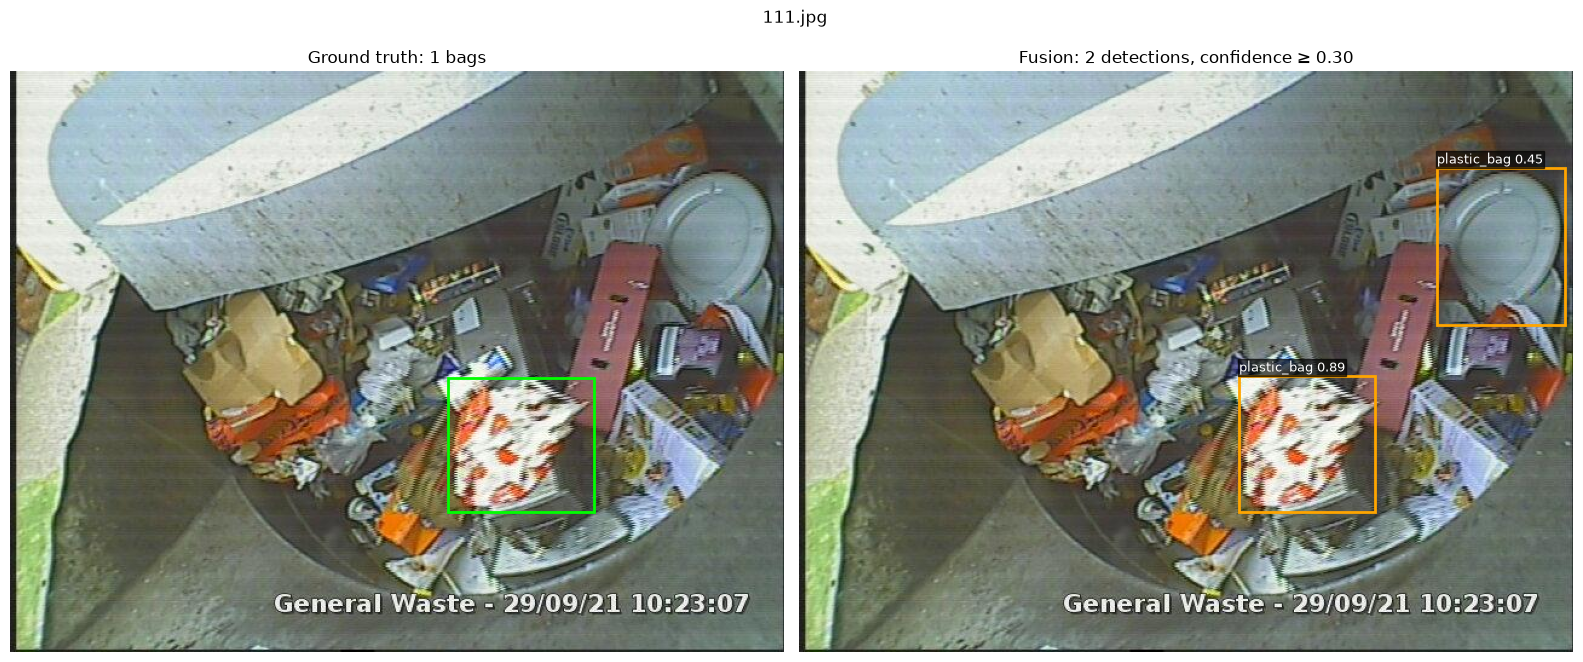

In [3]:
image_paths = sorted((DATA_ROOT / 'val' / 'image').glob('*.jpg'))
prediction_cache = {}

def show_image(index=0, confidence=0.30):
    path = image_paths[index]
    image = Image.open(path).convert('RGB')
    if index not in prediction_cache:
        tensor = torch.from_numpy(np.array(image).copy()).permute(2, 0, 1).float() / 255
        with torch.inference_mode():
            prediction_cache[index] = model([tensor])[0]
    pred = prediction_cache[index]
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax in axes:
        ax.imshow(image)
        ax.axis('off')
    label_path = DATA_ROOT / 'val' / 'label' / (path.stem + '.txt')
    ground_truth = []
    for line in label_path.read_text().splitlines():
        fields = line.split()
        if len(fields) >= 8 and fields[0] == 'plastic_bag':
            ground_truth.append(list(map(float, fields[4:8])))
    for x1, y1, x2, y2 in ground_truth:
        axes[0].add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='lime', linewidth=2))
    keep = pred['scores'] >= confidence
    for box, score in zip(pred['boxes'][keep], pred['scores'][keep]):
        x1, y1, x2, y2 = box.tolist()
        axes[1].add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='orange', linewidth=2))
        axes[1].text(x1, max(0, y1-4), f'plastic_bag {float(score):.2f}', color='white', fontsize=9,
                     bbox=dict(facecolor='black', alpha=0.65, pad=1))
    axes[0].set_title(f'Ground truth: {len(ground_truth)} bags')
    axes[1].set_title(f'Fusion: {int(keep.sum())} detections, confidence ≥ {confidence:.2f}')
    fig.suptitle(path.name)
    fig.tight_layout()
    plt.show()
    return fig

fig = show_image(0)
PREVIEW_DIR = PROJECT_ROOT / 'runs' / 'team_fusion_viewer'
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(PREVIEW_DIR / 'prediction_preview.png', dpi=140, bbox_inches='tight')


## Browse predictions
Select an image and adjust the display threshold. Lower thresholds show more detections; they do not change the frozen fusion recipe. Predictions are cached while this kernel stays open.

In [4]:
selector = widgets.Dropdown(options=[(p.name, i) for i, p in enumerate(image_paths)], description='Image:', layout=widgets.Layout(width='650px'))
threshold = widgets.FloatSlider(value=0.30, min=0.01, max=0.95, step=0.01, description='Confidence:', continuous_update=False)
output = widgets.interactive_output(lambda index, confidence: show_image(index, confidence), {'index': selector, 'confidence': threshold})
display(widgets.VBox([selector, threshold, output]))


## Try another image
Change `CUSTOM_IMAGE` to an image on this computer and run the cell. On another JupyterLab server, copy this repository, place the bundle in `models/team_fusion/`, and keep the dataset in `data/`. Paths are resolved relative to the project. Install `ultralytics==8.4.163`, `ipywidgets`, and `matplotlib` in that kernel if needed.

In [5]:
CUSTOM_IMAGE = ''  # Example: C:/Users/diego/Pictures/bag.jpg
if CUSTOM_IMAGE:
    custom = Image.open(CUSTOM_IMAGE).convert('RGB')
    tensor = torch.from_numpy(np.array(custom).copy()).permute(2, 0, 1).float() / 255
    with torch.inference_mode():
        result = model([tensor])[0]
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(custom)
    for box, score in zip(result['boxes'], result['scores']):
        if score < threshold.value:
            continue
        x1, y1, x2, y2 = box.tolist()
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='orange', linewidth=2))
        ax.text(x1, y1, f'{float(score):.2f}', color='white', bbox=dict(facecolor='black', alpha=0.6))
    ax.axis('off')
    plt.show()
